# **Noise2Void (3D) Prediction - CMCI**

---

<font size = 4> Noise2Void is a deep-learning method that can be used to denoise many types of images, including microscopy images and which was originally published by [Krull *et al.* on arXiv](https://arxiv.org/abs/1811.10980). It allows denoising of image data in a self-supervised manner, therefore high-quality, low noise equivalent images are not necessary to train this network. This is performed by "masking" a random subset of pixels in the noisy image and training the network to predict the values in these pixels. The resulting output is a denoised version of the image. Noise2Void is based on the popular U-Net network architecture, adapted from [CARE](https://www.nature.com/articles/s41592-018-0216-7).

<font size = 4> **This notebook allows users to select a previously-trained N2V-3D model to predict their data. This is not compatible with 2D datasets.**

---

<font size = 4>*Disclaimer*:

<font size = 4>This notebook is an extension of the Zero-Cost Deep-Learning to Enhance Microscopy project (https://github.com/HenriquesLab/DeepLearning_Collab/wiki). Jointly developed by the Jacquemet (link to https://cellmig.org/) and Henriques (https://henriqueslab.github.io/) laboratories.

<font size = 4>This notebook is largely based on the following paper:

<font size = 4>**Noise2Void - Learning Denoising from Single Noisy Images**
from Krull *et al.* published on arXiv in 2018 (https://arxiv.org/abs/1811.10980)

<font size = 4>And source code found in: https://github.com/juglab/n2v

<font size = 4>**Please also cite this original paper when using or developing this notebook.**




# **How to use this notebook:**

---

### **Structure of a notebook**

<font size = 4>The notebook contains two types of cell:  

<font size = 4>**Text cells** provide information and can be modified by douple-clicking the cell. You are currently reading the text cell. You can create a new text by clicking `+ Text`.

<font size = 4>**Code cells** contain code and the code can be modfied by selecting the cell. To execute the cell, move your cursor on the `[ ]`-mark on the left side of the cell (play button appears). Click to execute the cell. After execution is done the animation of play button stops. You can create a new coding cell by clicking `+ Code`.

---
### **Files, where to find them, how to prepare them**

<font size = 4>On the left hand side of the notebook, you will find a directory structure. Before you started the Docker container, you should have confirmed that the root directory contains your files.

<font size = 4>Your files should be split into individual channels, with each of the channel's data in their own separate folder.

<font size = 4>If that's not the case, move your files into the following location:
<font size = 4>          **D:\Data_for_restoration\user_data_input**

---

### **Running a model on your data**

<font size = 4> Several models have been trained for different datasets. N2V works best when it's trained on one "kind" of data, for example "cytoskeleton" or "yeast vacuole". We don't need to differentiate between "actin" and "microtubules" as much.
<font size = 4> You will need to select a model (see below) and point it at your data. The model will perform predictions across your dataset, and save de-noised (hopefully!) versions of your datasets in:
    **D:\Data_for_restoration\user_data_output\channel_**



In [ ]:
##We need to have a directory in which we store working models that is easily accessible by the user while they are using the Docker environment. 
# We read in the model directory names, then make a menu from these
#The user selects a model, which is then loaded, and points the notebook to a directory of single-channel images, which are predicted, and written to the disk
# The user also needs to input the name of the channel "mitochondria" or some such in order to differentiate the different channels


### **Install Dependencies** 

Run the cell below to install the required software components for the prediction to run

In [2]:
from datetime import datetime

internal_aux_initial_time=datetime.now()
print('Runnning...')
print('--------------------------------------')
# Run this cell to execute the code

import ipywidgets as widgets
from IPython.display import Markdown, display, clear_output
from matplotlib import pyplot as plt
import yaml as yaml_library
import os

ipywidgets_edit_yaml_config_path = os.path.join(os.getcwd(), 'results', 'widget_prev_settings.yaml')

def ipywidgets_edit_yaml(yaml_path, key, value):
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            config_data = yaml_library.safe_load(f)
    else:
        config_data = {}
    config_data[key] = value
    with open(yaml_path, 'w') as new_f:
        yaml_library.safe_dump(config_data, new_f, width=10e10, default_flow_style=False, allow_unicode=True)

def ipywidgets_read_yaml(yaml_path, key):
    if os.path.exists(yaml_path):
        with open(yaml_path, 'r') as f:
            config_data = yaml_library.safe_load(f)
        value = config_data.get(key, '')
        return value
    else:
        return ''

Notebook_version = '1.16.2'
Network = 'Noise2Void (3D)'

from builtins import any as b_any

def get_requirements_path():
    # Store requirements file in 'contents' directory 
    current_dir = os.getcwd()
    dir_count = current_dir.count('/') - 1
    path = '../' * (dir_count) + 'requirements.txt'
    return path

def filter_files(file_list, filter_list):
    filtered_list = []
    for fname in file_list:
        if b_any(fname.split('==')[0] in s for s in filter_list):
            filtered_list.append(fname)
    return filtered_list

def build_requirements_file(before, after):
    path = get_requirements_path()

    # Exporting requirements.txt for local run
    !pip freeze > $path

    # Get minimum requirements file
    df = pd.read_csv(path)
    mod_list = [m.split('.')[0] for m in after if not m in before]
    req_list_temp = df.values.tolist()
    req_list = [x[0] for x in req_list_temp]

    # Replace with package name and handle cases where import name is different to module name
    mod_name_list = [['sklearn', 'scikit-learn'], ['skimage', 'scikit-image']]
    mod_replace_list = [[x[1] for x in mod_name_list] if s in [x[0] for x in mod_name_list] else s for s in mod_list] 
    filtered_list = filter_files(req_list, mod_replace_list)

    file=open(path,'w')
    for item in filtered_list:
        file.writelines(item)

    file.close()

import sys
before = [str(m) for m in sys.modules]

import tensorflow
print('TensorFlow version:')
print(tensorflow.__version__)

print("Tensorflow enabled.")

%load_ext memory_profiler

# ------- Variable specific to N2V -------
from n2v.models import N2VConfig, N2V
from csbdeep.utils import plot_history
from n2v.utils.n2v_utils import manipulate_val_data
from n2v.internals.N2V_DataGenerator import N2V_DataGenerator
from csbdeep.io import save_tiff_imagej_compatible

# ------- Common variable to all ZeroCostDL4Mic notebooks -------
import numpy as np
from matplotlib import pyplot as plt
import urllib
import os, random
import shutil 
import zipfile
from tifffile import imread, imsave
import time
import sys
import wget
from pathlib import Path
import pandas as pd
import csv
from glob import glob
from scipy import signal
from scipy import ndimage
from skimage import io
from sklearn.linear_model import LinearRegression
from skimage.util import img_as_uint
import matplotlib as mpl
from skimage.metrics import structural_similarity
from skimage.metrics import peak_signal_noise_ratio as psnr
from astropy.visualization import simple_norm
from skimage import img_as_float32
from fpdf import FPDF, HTMLMixin
from datetime import datetime
from pip._internal.operations.freeze import freeze
import subprocess

#Create a variable to get and store relative base path
base_path = os.getcwd()

# Colors for the warning messages
class bcolors:
  WARNING = '\033[31m'
W  = '\033[0m'  # white (normal)
R  = '\033[31m' # red

#Disable some of the tensorflow warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries installed")

# Check if this is the latest version of the notebook
All_notebook_versions = pd.read_csv("https://raw.githubusercontent.com/HenriquesLab/ZeroCostDL4Mic/master/Colab_notebooks/Latest_Notebook_versions.csv", dtype=str)
print('Notebook version: '+Notebook_version)
Latest_Notebook_version = All_notebook_versions[All_notebook_versions["Notebook"] == Network]['Version'].iloc[0]
print('Latest notebook version: '+Latest_Notebook_version)
if Notebook_version == Latest_Notebook_version:
  print("This notebook is up-to-date.")
else:
  print(bcolors.WARNING +"A new version of this notebook has been released. We recommend that you download it at https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki")

def pdf_export(trained = False, augmentation = False, pretrained_model = False):
  class MyFPDF(FPDF, HTMLMixin):
    pass

  pdf = MyFPDF()
  pdf.add_page()
  pdf.set_right_margin(-1)
  pdf.set_font("Arial", size = 11, style='B') 

  Network = 'Noise2Void 3D'
  day = datetime.now()
  datetime_str = str(day)[0:10]

  Header = 'Training report for '+Network+' model ('+model_name+')\nDate: '+datetime_str
  pdf.multi_cell(180, 5, txt = Header, align = 'L') 
  pdf.ln(1)
    
  # add another cell 
  if trained:
    training_time = "Training time: "+str(hour)+ "hour(s) "+str(mins)+"min(s) "+str(round(sec))+"sec(s)"
    pdf.cell(190, 5, txt = training_time, ln = 1, align='L')
  pdf.ln(1)

  Header_2 = 'Information for your materials and method:'
  pdf.cell(190, 5, txt=Header_2, ln=1, align='L')

  all_packages = ''
  for requirement in freeze(local_only=True):
    all_packages = all_packages+requirement+', '
  #print(all_packages)

  #Main Packages
  main_packages = ''
  version_numbers = []
  for name in ['tensorflow','numpy','Keras','csbdeep']:
    find_name=all_packages.find(name)
    main_packages = main_packages+all_packages[find_name:all_packages.find(',',find_name)]+', '
    #Version numbers only here:
    version_numbers.append(all_packages[find_name+len(name)+2:all_packages.find(',',find_name)])

  try:
    cuda_version = subprocess.run(["nvcc","--version"],stdout=subprocess.PIPE)
    cuda_version = cuda_version.stdout.decode('utf-8')
    cuda_version = cuda_version[cuda_version.find(', V')+3:-1]
  except:
    cuda_version = ' - No cuda found - '
  try:
    gpu_name = subprocess.run(["nvidia-smi"],stdout=subprocess.PIPE)
    gpu_name = gpu_name.stdout.decode('utf-8')
    gpu_name = gpu_name[gpu_name.find('Tesla'):gpu_name.find('Tesla')+10]
  except:
    gpu_name = ' - No GPU found - '
  #print(cuda_version[cuda_version.find(', V')+3:-1])
  #print(gpu_name)

  shape = io.imread(Training_source+'/'+os.listdir(Training_source)[0]).shape
  dataset_size = len(os.listdir(Training_source))

  text = 'The '+Network+' model was trained from scratch for '+str(number_of_epochs)+' epochs on '+str(len(patches))+' image patches (image dimensions: '+str(shape)+', patch size: ('+str(patch_height)+','+str(patch_size)+','+str(patch_size)+')) with a batch size of '+str(batch_size)+' and a '+config.train_loss+' loss function, using the '+Network+' ZeroCostDL4Mic notebook (v '+Notebook_version[0]+') (von Chamier & Laine et al., 2020). Key python packages used include tensorflow (v '+version_numbers[0]+'), Keras (v '+version_numbers[2]+'), csbdeep (v '+version_numbers[3]+'), numpy (v '+version_numbers[1]+'), cuda (v '+cuda_version+'). The training was accelerated using a '+gpu_name+'GPU.'

  if pretrained_model:
    text = 'The '+Network+' model was trained for '+str(number_of_epochs)+' epochs on '+str(len(patches))+' paired image patches (image dimensions: '+str(shape)+', patch size: ('+str(patch_height)+','+str(patch_size)+','+str(patch_size)+')) with a batch size of '+str(batch_size)+' and a '+config.train_loss+' loss function, using the '+Network+' ZeroCostDL4Mic notebook (v '+Notebook_version[0]+') (von Chamier & Laine et al., 2020). The model was re-trained from a pretrained model. Key python packages used include tensorflow (v '+version_numbers[0]+'), Keras (v '+version_numbers[2]+'), csbdeep (v '+version_numbers[3]+'), numpy (v '+version_numbers[1]+'), cuda (v '+cuda_version+'). The training was accelerated using a '+gpu_name+'GPU.'

  pdf.set_font('')
  pdf.set_font_size(10.)
  pdf.multi_cell(190, 5, txt = text, align='L')
  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.ln(1)
  pdf.cell(26, 5, txt='Augmentation: ', ln=0)
  pdf.set_font('')
  if augmentation:
    aug_text = 'The dataset was augmented by default.'
  else:
    aug_text = 'No augmentation was used for training.'
  pdf.multi_cell(190, 5, txt=aug_text, align='L')
  pdf.ln(1)
  pdf.set_font('Arial', size = 11, style = 'B')
  pdf.ln(1)
  pdf.cell(180, 5, txt = 'Parameters', align='L', ln=1)
  pdf.set_font('')
  pdf.set_font_size(10.)
  if Use_Default_Advanced_Parameters:
    pdf.cell(200, 5, txt='Default Advanced Parameters were enabled')
  pdf.cell(200, 5, txt='The following parameters were used for training:')
  pdf.ln(1)
  html = """ 
  <table width=40% style="margin-left:0px;">
    <tr>
      <th width = 50% align="left">Parameter</th>
      <th width = 50% align="left">Value</th>
    </tr>
    <tr>
      <td width = 50%>number_of_epochs</td>
      <td width = 50%>{0}</td>
    </tr>
    <tr>
      <td width = 50%>patch_size</td>
      <td width = 50%>{1}</td>
    </tr>
    <tr>
      <td width = 50%>batch_size</td>
      <td width = 50%>{2}</td>
    </tr>
    <tr>
      <td width = 50%>number_of_steps</td>
      <td width = 50%>{3}</td>
    </tr>
    <tr>
      <td width = 50%>percentage_validation</td>
      <td width = 50%>{4}</td>
    </tr>
    <tr>
      <td width = 50%>initial_learning_rate</td>
      <td width = 50%>{5}</td>
    </tr>
  </table>
  """.format(number_of_epochs,str(patch_height)+'x'+str(patch_size)+'x'+str(patch_size),batch_size,number_of_steps,percentage_validation,initial_learning_rate)
  pdf.write_html(html)

  #pdf.multi_cell(190, 5, txt = text_2, align='L')
  pdf.set_font("Arial", size = 11, style='B')
  pdf.ln(1)
  pdf.cell(190, 5, txt = 'Training Dataset', align='L', ln=1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.cell(29, 5, txt= 'Training_source:', align = 'L', ln=0)
  pdf.set_font('')
  pdf.multi_cell(170, 5, txt = Training_source, align = 'L')
  pdf.ln(1)
  # pdf.set_font('')
  # pdf.set_font('Arial', size = 10, style = 'B')
  # pdf.cell(28, 5, txt= 'Training_target:', align = 'L', ln=0)
  # pdf.set_font('')
  # pdf.multi_cell(170, 5, txt = Training_target, align = 'L')
  #pdf.cell(190, 5, txt=aug_text, align='L', ln=1)
  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.cell(21, 5, txt= 'Model Path:', align = 'L', ln=0)
  pdf.set_font('')
  pdf.multi_cell(170, 5, txt = model_path+'/'+model_name, align = 'L')
  pdf.ln(1)
  pdf.cell(60, 5, txt = 'Training Image', ln=1)
  pdf.ln(1)
  exp_size = io.imread(base_path + '/TrainingDataExample_N2V3D.png').shape
  pdf.image(base_path + '/TrainingDataExample_N2V3D.png', x = 11, y = None, w = round(exp_size[1]/8), h = round(exp_size[0]/8))
  pdf.ln(1)
  ref_1 = 'References:\n - ZeroCostDL4Mic: von Chamier, Lucas & Laine, Romain, et al. "Democratising deep learning for microscopy with ZeroCostDL4Mic." Nature Communications (2021).'
  pdf.multi_cell(190, 5, txt = ref_1, align='L')
  pdf.ln(1)
  ref_2 = '- Noise2Void: Krull, Alexander, Tim-Oliver Buchholz, and Florian Jug. "Noise2void-learning denoising from single noisy images." Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition. 2019.'
  pdf.multi_cell(190, 5, txt = ref_2, align='L')
  pdf.ln(1)
  # if Use_Data_augmentation:
  #   ref_3 = '- Augmentor: Bloice, Marcus D., Christof Stocker, and Andreas Holzinger. "Augmentor: an image augmentation library for machine learning." arXiv preprint arXiv:1708.04680 (2017).'
  #   pdf.multi_cell(190, 5, txt = ref_3, align='L')
  pdf.ln(3)
  reminder = 'Important:\nRemember to perform the quality control step on all newly trained models\nPlease consider depositing your training dataset on Zenodo'
  pdf.set_font('Arial', size = 11, style='B')
  pdf.multi_cell(190, 5, txt=reminder, align='C')
  pdf.ln(1)

  pdf.output(model_path+'/'+model_name+'/'+model_name+"_training_report.pdf")

def qc_pdf_export():
  class MyFPDF(FPDF, HTMLMixin):
    pass

  pdf = MyFPDF()
  pdf.add_page()
  pdf.set_right_margin(-1)
  pdf.set_font("Arial", size = 11, style='B') 

  Network = 'Noise2Void 3D'
  day = datetime.now()
  datetime_str = str(day)[0:10]

  Header = 'Quality Control report for '+Network+' model ('+QC_model_name+')\nDate: '+datetime_str
  pdf.multi_cell(180, 5, txt = Header, align = 'L') 
  pdf.ln(1)

  all_packages = ''
  for requirement in freeze(local_only=True):
    all_packages = all_packages+requirement+', '

  pdf.set_font('')
  pdf.set_font('Arial', size = 11, style = 'B')
  pdf.ln(2)
  pdf.cell(190, 5, txt = 'Development of Training Losses', ln=1, align='L')
  exp_size = io.imread(full_QC_model_path+'/Quality Control/QC_example_data.png').shape
  if os.path.exists(full_QC_model_path+'/Quality Control/lossCurvePlots.png'):
    pdf.image(full_QC_model_path+'/Quality Control/lossCurvePlots.png', x = 11, y = None, w = round(exp_size[1]/10), h = round(exp_size[0]/13))
  else:
    pdf.set_font('')
    pdf.set_font('Arial', size=10)
    # pdf.ln(3)
    pdf.multi_cell(190, 5, txt='If you would like to see the evolution of the loss function during training please play the first cell of the QC section in the notebook.')
  pdf.ln(3)
  pdf.set_font('')
  pdf.set_font('Arial', size = 10, style = 'B')
  pdf.ln(3)
  pdf.cell(80, 5, txt = 'Example Quality Control Visualisation', ln=1)
  pdf.ln(1)
  exp_size = io.imread(full_QC_model_path+'/Quality Control/QC_example_data.png').shape
  pdf.image(full_QC_model_path+'/Quality Control/QC_example_data.png', x = 16, y = None, w = round(exp_size[1]/10), h = round(exp_size[0]/10))
  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font('Arial', size = 11, style = 'B')
  pdf.ln(1)
  pdf.cell(180, 5, txt = 'Quality Control Metrics', align='L', ln=1)
  pdf.set_font('')
  pdf.set_font_size(10.)

  pdf.ln(1)
  html = """
  <body>
  <font size="7" face="Courier" >
  <table width=97% style="margin-left:0px;">"""
  with open(full_QC_model_path+'/Quality Control/QC_metrics_'+QC_model_name+'.csv', 'r') as csvfile:
    metrics = csv.reader(csvfile)
    header = next(metrics)
    image = header[0]
    slice_n = header[1]
    mSSIM_PvsGT = header[2]
    mSSIM_SvsGT = header[3]
    NRMSE_PvsGT = header[4]
    NRMSE_SvsGT = header[5]
    PSNR_PvsGT = header[6]
    PSNR_SvsGT = header[7]
    header = """
    <tr>
    <th width = 9% align="left">{0}</th>
    <th width = 4% align="left">{1}</th>
    <th width = 15% align="center">{2}</th>
    <th width = 14% align="left">{3}</th>
    <th width = 15% align="center">{4}</th>
    <th width = 14% align="left">{5}</th>
    <th width = 15% align="center">{6}</th>
    <th width = 14% align="left">{7}</th>
    </tr>""".format(image,slice_n,mSSIM_PvsGT,mSSIM_SvsGT,NRMSE_PvsGT,NRMSE_SvsGT,PSNR_PvsGT,PSNR_SvsGT)
    html = html+header
    for row in metrics:
      image = row[0]
      slice_n = row[1]
      mSSIM_PvsGT = row[2]
      mSSIM_SvsGT = row[3]
      NRMSE_PvsGT = row[4]
      NRMSE_SvsGT = row[5]
      PSNR_PvsGT = row[6]
      PSNR_SvsGT = row[7]
      cells = """
        <tr>
          <td width = 9% align="left">{0}</td>
          <td width = 4% align="center">{1}</td>
          <td width = 15% align="center">{2}</td>
          <td width = 14% align="center">{3}</td>
          <td width = 15% align="center">{4}</td>
          <td width = 14% align="center">{5}</td>
          <td width = 15% align="center">{6}</td>
          <td width = 14% align="center">{7}</td>
        </tr>""".format(image,slice_n,str(round(float(mSSIM_PvsGT),3)),str(round(float(mSSIM_SvsGT),3)),str(round(float(NRMSE_PvsGT),3)),str(round(float(NRMSE_SvsGT),3)),str(round(float(PSNR_PvsGT),3)),str(round(float(PSNR_SvsGT),3)))
      html = html+cells
    html = html+"""</body></table>"""
    
  pdf.write_html(html)

  pdf.ln(1)
  pdf.set_font('')
  pdf.set_font_size(10.)
  ref_1 = 'References:\n - ZeroCostDL4Mic: von Chamier, Lucas & Laine, Romain, et al. "Democratising deep learning for microscopy with ZeroCostDL4Mic." Nature Communications (2021).'
  pdf.multi_cell(190, 5, txt = ref_1, align='L')
  pdf.ln(1)
  ref_2 = '- Noise2Void: Krull, Alexander, Tim-Oliver Buchholz, and Florian Jug. "Noise2void-learning denoising from single noisy images." Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition. 2019.'
  pdf.multi_cell(190, 5, txt = ref_2, align='L')
  pdf.ln(1)

  pdf.ln(3)
  reminder = 'To find the parameters and other information about how this model was trained, go to the training_report.pdf of this model which should be in the folder of the same name.'

  pdf.set_font('Arial', size = 11, style='B')
  pdf.multi_cell(190, 5, txt=reminder, align='C')
  pdf.ln(1)

  pdf.output(full_QC_model_path+'/Quality Control/'+QC_model_name+'_QC_report.pdf')

# Build requirements file for local run
after = [str(m) for m in sys.modules]
build_requirements_file(before, after)
print('--------------------------------------')
print(f'Finished. Duration: {datetime.now() - internal_aux_initial_time}')

Runnning...
--------------------------------------


2026-07-10 14:18:51.493773: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-10 14:18:52.379694: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-10 14:18:53.583216: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: lib/:/usr/local/lib/python3.10/dist-packages/nvidia/cudnn/lib:/usr/local/cuda/extras/CUPTI/lib64:/usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-07-10 14:18:53.584504: W tensorflow/stream_executor/platform/def

TensorFlow version:
2.10.1
Tensorflow enabled.
Libraries installed
Notebook version: 1.16.2
Latest notebook version: 1.16.2
This notebook is up-to-date.
--------------------------------------
Finished. Duration: 0:00:07.889910


In [22]:
import json

# Run this cell to execute the code
internal_aux_initial_time=datetime.now()
print('Runnning...')
print('--------------------------------------')
# Run this cell to visualize the parameters and click the button to execute the code
internal_aux_initial_time=datetime.now()
clear_output()

allModels_path = "/home/results/models/"
if allModels_path[-1] != '/':
    allModels_path = allModels_path+"/"
    
modelList = os.listdir(allModels_path)


display(Markdown("### Path to images: "))
widget_prediction_source = widgets.Text(value="", style={'description_width': 'initial'}, description="prediction_source:")
display(widget_prediction_source)

display(Markdown("### Model name and path:"))
widget_model_name = widgets.Dropdown(options = modelList,value=modelList[0], description="model_name:")
display(widget_model_name)

display(Markdown("### What should the channel be called:"))
widget_channel_name = widgets.Text(value="", style={'description_width': 'initial'}, description="channel_name:")
display(widget_channel_name)



def function_9(output_widget):
  output_widget.clear_output()
  with output_widget:
    global prediction_source
    global model_name
    #global model_path
    global channel_name
    
    model_name = widget_model_name.value
    channel_name = widget_channel_name.value
    
    with open(allModels_path+model_name+"/config.json") as f:
        model_parms = json.load(f)
        print(model_parms["n2v_patch_shape"])
        patch_size = model_parms["n2v_patch_shape"][1]
        patch_height = model_parms["n2v_patch_shape"][0]


    # Create DataGenerator-object.
    datagen = N2V_DataGenerator()
    
    prediction_source = widget_prediction_source.value
    prediction_source = "/home/"+prediction_source
    
    if prediction_source[-1] !='/':
        prediction_source = prediction_source+'/'
    
  
    
    random_choice=random.choice(os.listdir(prediction_source))
    x = imread(prediction_source+"/"+random_choice)
    
    # Here we check that the input images are stacks
    if len(x.shape) == 3:
      print("Image dimensions (z,y,x)",x.shape)
    
    if not len(x.shape) == 3:
      print(bcolors.WARNING + "Your images appear to have the wrong dimensions. Image dimension",x.shape)
    
    #Find image Z dimension and select the mid-plane
    Image_Z = x.shape[0]
    mid_plane = int(Image_Z / 2)+1
    
    #Find image XY dimension
    Image_Y = x.shape[1]
    Image_X = x.shape[2]
    
    #Hyperparameters failsafes
    
    # Here we check that patch_size is smaller than the smallest xy dimension of the image 
    if patch_size > min(Image_Y, Image_X):
      patch_size = min(Image_Y, Image_X)
      print (bcolors.WARNING + " Your chosen patch_size is bigger than the xy dimension of your image; therefore the patch_size chosen is now:",patch_size)
    
    # Here we check that patch_size is divisible by 8
    if not patch_size % 8 == 0:
        patch_size = ((int(patch_size / 8)-1) * 8)
        print (bcolors.WARNING + " Your chosen patch_size is not divisible by 8; therefore the patch_size chosen is now:",patch_size)
    
    # Here we check that patch_height is smaller than the z dimension of the image 
    if patch_height > Image_Z :
      patch_height = Image_Z
      print (bcolors.WARNING + " Your chosen patch_height is bigger than the z dimension of your image; therefore the patch_size chosen is now:",patch_height)
    
    # Here we check that patch_height is divisible by 4
    if not patch_height % 4 == 0:
        patch_height = ((int(patch_height / 4)-1) * 4)
        if patch_height == 0:
          patch_height = 4
        print (bcolors.WARNING + " Your chosen patch_height is not divisible by 4; therefore the patch_size chosen is now:",patch_height)
    
    # Here we disable pre-trained model by default (in case the next cell is not run)
    Use_pretrained_model = False
    
    # Here we enable data augmentation by default (in case the cell is not ran)
    
    Use_Data_augmentation = True
    
    print("Parameters initiated.")
    
    #Here we display a single z plane
    
    norm = simple_norm(x[mid_plane], percent = 99)
    
    f=plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.imshow(x[mid_plane], interpolation='nearest', norm=norm, cmap='magma')
    plt.title('Prediction source')
    plt.axis('off');
    plt.savefig(base_path + '/TrainingDataExample_N2V3D.png',bbox_inches='tight',pad_inches=0)
    
    plt.show()
'''
def function_9_cache(output_widget):
    global prediction_source
    global model_name
    global channel_name
   '''
button_function_9 = widgets.Button(description='Load and run')
#cache_button_function_9 = widgets.Button(description='Load prev. settings')
output_function_9 = widgets.Output()
display(button_function_9, output_function_9)
def aux_function_9(_):
  return function_9(output_function_9)

#def aux_function_9_cache(_):
 # return function_9_cache(output_function_9)

button_function_9.on_click(aux_function_9)
#cache_button_function_9.on_click(aux_function_9_cache)
print('--------------------------------------------------------------')
print('^ Introduce the arguments and click "Load and run". ^')
print('--------------------------------------')
print(f'Finished. Duration: {datetime.now() - internal_aux_initial_time}')

### Path to images: 

Text(value='', description='prediction_source:', style=TextStyle(description_width='initial'))

### Model name and path:

Dropdown(description='model_name:', options=('cicero_actin', 'SR_SD_Natasha'), value='cicero_actin')

### What should the channel be called:

Text(value='', description='channel_name:', style=TextStyle(description_width='initial'))

Button(description='Load and run', style=ButtonStyle())

Output()

--------------------------------------------------------------
^ Introduce the arguments and click "Load and run". ^
--------------------------------------
Finished. Duration: 0:00:00.023030


Using current trained network
/home/results/models/
The cicero_actin network will be used.
Loading network weights from 'weights_best.h5'.
Denoising images...
/home/data/input/Test2/20250725_n2v_cicero__1_MMStack_Pos0.ome.tif
/home/data/input/Test2 20250725_n2v_cicero__1_MMStack_Pos0.ome.tif
The input image is of type uint16 and will be casted to float32 for prediction.
1/1 [==============================] - 0s 453ms/step


 25%|████████████████████▎                                                            | 1/4 [00:00<00:00, 82241.25it/s]

1/1 [==============================] - 0s 101ms/step


 50%|██████████████████████████████████████████                                          | 2/4 [00:01<00:01,  1.14it/s]

1/1 [==============================] - 0s 95ms/step


 75%|███████████████████████████████████████████████████████████████                     | 3/4 [00:03<00:01,  1.21s/it]

1/1 [==============================] - 0s 100ms/step


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.29s/it]


/home/results/output/act_20250725_n2v_cicero__1_MMStack_Pos0.ome.tif
Prediction of images done.
One example is displayed here.


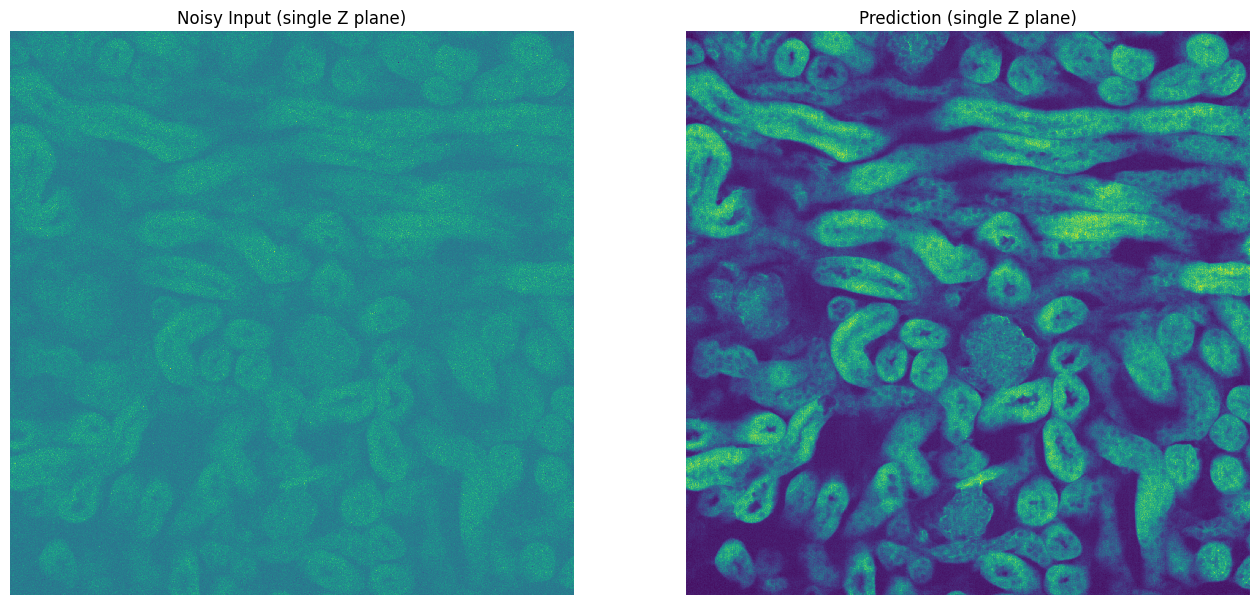

In [45]:
#Activate the pretrained model. 
#model_training = CARE(config=None, name=model_name, basedir=model_path)

#@markdown ### Provide the path to your dataset and to the folder where the prediction will be saved, then play the cell to predict output on your unseen images.

#@markdown ###Path to data to analyse and where predicted output should be saved:
Data_folder = "" #@param {type:"string"}
Result_folder = "" #@param {type:"string"}


# model name and path
#@markdown ###Do you want to use the current trained model?
Use_the_current_trained_model = True #@param {type:"boolean"}

#@markdown ###If not, please provide the path to the model folder:

Prediction_model_folder = "" #@param {type:"string"}

#Here we find the loaded model name and parent path
Prediction_model_name = os.path.basename(Prediction_model_folder)
Prediction_model_path = os.path.dirname(Prediction_model_folder)

if (Use_the_current_trained_model): 
  print("Using current trained network")
  Prediction_model_name = model_name
  Prediction_model_path = allModels_path
print(Prediction_model_path)

full_Prediction_model_path = allModels_path+model_name+'/'
if os.path.exists(full_Prediction_model_path):
  print("The "+Prediction_model_name+" network will be used.")
else:  
  print(bcolors.WARNING + '!! WARNING: The chosen model does not exist !!')
  print('Please make sure you provide a valid model path and model name before proceeding further.')

#Here we allow the user to choose the number of tile to be used when predicting the images
#@markdown #####To analyse large image, your images need to be divided into tiles.  Each tile will then be processed independently and re-assembled to generate the final image. "Automatic_number_of_tiles" will search for and use the smallest number of tiles that can be used, at the expanse of your runtime. Alternatively, manually input the number of tiles in each dimension to be used to process your images. 

Automatic_number_of_tiles = False #@param {type:"boolean"}
#@markdown #####If you get an Out of memory (OOM) error when using the "Automatic_number_of_tiles" option, disable it and manually input the values to be used to process your images.  Progressively increases these numbers until the OOM error disappear.
n_tiles_Z =  1#@param {type:"number"}
n_tiles_Y =  2#@param {type:"number"}
n_tiles_X =  2#@param {type:"number"}

if (Automatic_number_of_tiles): 
  n_tilesZYX = None

if not (Automatic_number_of_tiles):
  n_tilesZYX = (n_tiles_Z, n_tiles_Y, n_tiles_X)

#Activate the pretrained model.
config = None
model = N2V(config, model_name, basedir=Prediction_model_path)

print("Denoising images...")

thisdir = Path(prediction_source)
outputdir = Path("/home/results/output/")
suffix = '.tif'

# r=root, d=directories, f = files
for r, d, f in os.walk(thisdir):
    for file in f:
        if ".tif" in file:
            print(os.path.join(r, file))
            


# The code by Lucas von Chamier
for r, d, f in os.walk(thisdir):
  for file in f:
    base_filename = os.path.basename(file)
    print(r,file)
    input_train = imread(os.path.join(r, file))
    pred_train = model.predict(input_train, axes='ZYX', n_tiles=n_tilesZYX)
    print("/home/results/output/"+channel_name+"_"+ base_filename)
    save_tiff_imagej_compatible("/home/results/output/"+channel_name+"_"+ base_filename, pred_train, axes='ZYX')
            
print("Prediction of images done.")

print("One example is displayed here.")


#Display an example
random_choice=random.choice(os.listdir(prediction_source))
x = imread(prediction_source+random_choice)

#Find image Z dimension and select the mid-plane
Image_Z = x.shape[0]
mid_plane = int(Image_Z / 2)+1

y = imread("/home/results/output/"+channel_name+"_"+random_choice)

f=plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.imshow(x[mid_plane], interpolation='nearest')
plt.title('Noisy Input (single Z plane)');
plt.axis('off');
plt.subplot(1,2,2)
plt.imshow(y[mid_plane], interpolation='nearest')
plt.title('Prediction (single Z plane)');
plt.axis('off');